# Анализ сотрудников компании и факторов увольнений (поиск инсайтов, составление рекомендаций стейкхолдерам).

Задачи:  

1.	Анализ сотрудников компании и факторов увольнений (поиск инсайтов, составление рекомендаций стейкхолдерам).   
2.	Построение модели для дальнейшего прогнозирования возможных увольнений.

Загрузка необходимых библиотек.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import SelectKBest
from sklearn.preprocessing import StandardScaler
import numpy as np
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import confusion_matrix

Загрузка датасета IBM HR Analytics Employee Attrition & Performance.

In [ ]:
staff = pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition[1].csv')

staff.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


## Разведовательный анализ данных.

Вывод общей информации по столбцам.

In [ ]:
staff.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

### Описания набора данных

1. Профиль сотрудника (Личные данные)
* Age: Возраст.
* Gender: Пол.
* MaritalStatus: Семейное положение.
* Education: Уровень образования.
* EducationField: Направление образования.
* Over18: Совершеннолетний ли сотрудник.
2. Работа и карьера
*  Department: Департамент.
* JobRole: Должность.
* JobLevel: Уровень позиции.
* BusinessTravel: Частота командировок.
* TotalWorkingYears: Общий стаж работы за всю жизнь.
* YearsAtCompany: Стаж в текущей компании.
* YearsInCurrentRole: Сколько лет на текущей должности.
* YearsSinceLastPromotion: Сколько лет прошло с последнего повышения.
* YearsWithCurrManager: Сколько лет работает под началом текущего начальника.
3. Деньги
* MonthlyIncome: Ежемесячная зарплата (чистый доход).
* DailyRate / HourlyRate / MonthlyRate: Дневная, часовая и расчетная месячная ставки (используются для внутреннего учета).
* PercentSalaryHike: Процент последнего повышения зарплаты.
* StockOptionLevel: Уровень опционов (акций компании), выданных сотруднику.
4. Психология и Лояльность
* EnvironmentSatisfaction: Удовлетворенность рабочей средой.
* JobSatisfaction: Удовлетворенность самой работой.
* RelationshipSatisfaction: Отношения с коллегами/руководством.
* WorkLifeBalance: Баланс между работой и личной жизнью.
* JobInvolvement: Степень вовлеченности в процессы.
* PerformanceRating: Оценка эффективности.
5. Режим работы и разное
* Attrition: Целевая переменная (Уволился — Yes, Остался — No).
* OverTime: Работает ли сверхурочно (Yes/No).
* DistanceFromHome: Расстояние от дома до работы (в км или милях).
* NumCompaniesWorked: В скольких компаниях работал до этого.
* TrainingTimesLastYear: Кол-во пройденных тренингов за прошлый год.
* EmployeeCount: Счетчик сотрудника.
* StandardHours: Норма часов.
* EmployeeNumber: ID сотрудника.

Проверка на наличие пропусков.

In [ ]:
staff.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


Просмотр общей статистики.

In [ ]:
staff.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


На основании полученных результатов можно сказать следующее:

* В данных отсутствуют пропуски, это хорошо.   
* Около половины столбцов несмотря на то, что они числовые, это категории.   
* В некоторых столбцах, таких как расстояние до дома,зарплата,годы работы в компании и годы работы с текущим руководителем, присутствуют выбросы (большой разброс значений).

### Создание портрета уволившегося сотрудника.

In [ ]:
staff_mode = staff[staff['Attrition'] == 'Yes'].mode().iloc[:1].T
staff_mode

,0
Age,29.0
Attrition,Yes
BusinessTravel,Travel_Rarely
DailyRate,240.0
Department,Research & Development
DistanceFromHome,2.0
Education,3.0
EducationField,Life Sciences
EmployeeCount,1.0
EmployeeNumber,1


Портрет уволившегося получился следующим:   

Мужчина до 30 лет, живущий недалеко от работы, не женатый. По образованию бакалавр в области естественных наук. С редкими командировками, работал в отделе исследований и разработки на должности лаборанта, с самым начальным уровнем. Получал зарплату ниже тарифной ставки и это с учетом переработок, при этом показывал хорошую производительность и вовлеченность в работу. К тому же был не очень удовлетворен отношениями в коллективе и атмосферой на работе в целом.

## Анализ психологических факторов сотрудников.

Исходя из получившегося портрета уволившегося сотрудника, считаю необходимым посмотреть соотношение сотрудников по колонкам с психологическими факторами:   

* Удовлетворенность окружающей средой.
* Удовлетворенность работой.
* Оценка производительности.
* Удовлетворенность отношениями.
* Баланс работы и личной жизни.
* Уровень вовлеченности в работу.
* Образование.

Удовлетворенность окружающей средой.  
1. 'Low'
2. 'Medium'
3. 'High'
4. 'Very High'

In [ ]:
staff.groupby('Attrition')['EnvironmentSatisfaction'].value_counts().unstack(0)

Attrition,No,Yes
EnvironmentSatisfaction,,
1,212,72
2,244,43
3,391,62
4,386,60


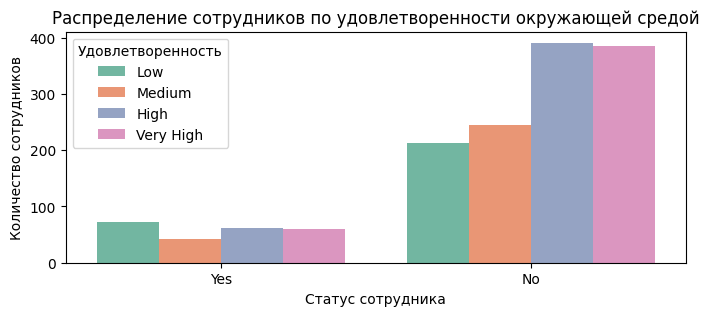

In [ ]:
EnvironmentSatisfaction_labels = ['Low','Medium','High','Very High']
plt.figure(figsize=(8,3))
sns.countplot(x="Attrition", hue="EnvironmentSatisfaction", data=staff, palette='Set2')
plt.title("Распределение сотрудников по удовлетворенности окружающей средой")
plt.xlabel('Статус сотрудника')
plt.ylabel('Количество сотрудников')
plt.legend(labels=EnvironmentSatisfaction_labels, title='Удовлетворенность')
plt.show()

Согласно графику и полученным значениям, больше половины уволившихся сотрудников не довольны окружающей средой на работе.

Удовлетворенность работой.   
1. 'Low'
2. 'Medium'
3. 'High'
4. 'Very High'

In [ ]:
staff.groupby('Attrition')['JobSatisfaction'].value_counts().unstack(0)

Attrition,No,Yes
JobSatisfaction,,
1,223,66
2,234,46
3,369,73
4,407,52


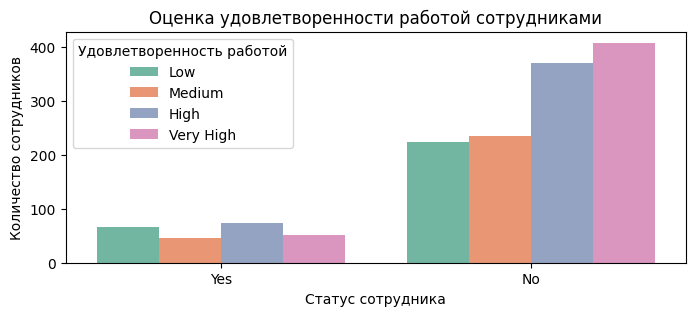

In [ ]:
JobSatisfaction_labels = ['Low','Medium','High','Very High']
plt.figure(figsize=(8,3))
sns.countplot(x="Attrition", hue="JobSatisfaction", data=staff, palette='Set2')
plt.title("Оценка удовлетворенности работой сотрудниками")
plt.xlabel('Статус сотрудника')
plt.ylabel('Количество сотрудников')
plt.legend(labels=JobSatisfaction_labels, title='Удовлетворенность работой')
plt.show()

На основании графика и данных, можно сказать что основную часть уволившихся вполне устраивали условия работы.

Оценка производительности.   
1. 'Low'
2. 'Good'
3. 'Excellent'
4. 'Outstanding'

In [ ]:
staff.groupby('Attrition')['PerformanceRating'].value_counts().unstack(0)

Attrition,No,Yes
PerformanceRating,,
3,1044,200
4,189,37


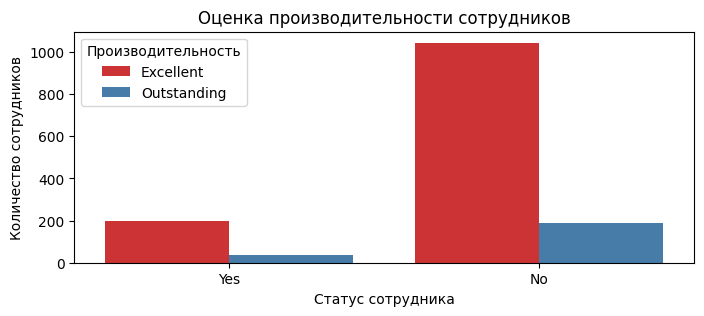

In [ ]:
PerformanceRating_labels = ['Excellent','Outstanding']
plt.figure(figsize=(8,3))
sns.countplot(x="Attrition", hue="PerformanceRating", data=staff, palette='Set1')
plt.title("Оценка производительности сотрудников")
plt.xlabel('Статус сотрудника')
plt.ylabel('Количество сотрудников')
plt.legend(labels=PerformanceRating_labels,title='Производительность')
plt.show()

Согласно графику и значениям, почти все уволившиеся сотрудники показывали очень хорошую производительность, а значит качественно и добросовестно выполняли свои обязаности.

Удовлетворенность отношениями.   
1. 'Low'
2. 'Medium'
3. 'High'
4. 'Very High'

In [ ]:
staff.groupby('Attrition')['RelationshipSatisfaction'].value_counts().unstack(0)

Attrition,No,Yes
RelationshipSatisfaction,,
1,219,57
2,258,45
3,388,71
4,368,64


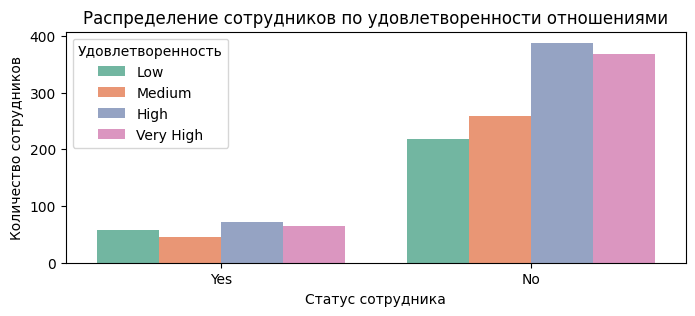

In [ ]:
RelationshipSatisfaction_labels = ['Low','Medium','High','Very High']
plt.figure(figsize=(8,3))
sns.countplot(x="Attrition", hue="RelationshipSatisfaction", data=staff, palette='Set2')
plt.title("Распределение сотрудников по удовлетворенности отношениями")
plt.xlabel('Статус сотрудника')
plt.ylabel('Количество сотрудников')
plt.legend(labels=RelationshipSatisfaction_labels, title='Удовлетворенность')
plt.show()

По полученному графику можно сказать, что больше половины уволившихся устраивали отношения в коллективе.

Баланс работы и личной жизни.   
1. 'Bad'
2. 'Good'
3. 'Better'
4. 'Best'

In [ ]:
staff.groupby('Attrition')['WorkLifeBalance'].value_counts().unstack(0)

Attrition,No,Yes
WorkLifeBalance,,
1,55,25
2,286,58
3,766,127
4,126,27


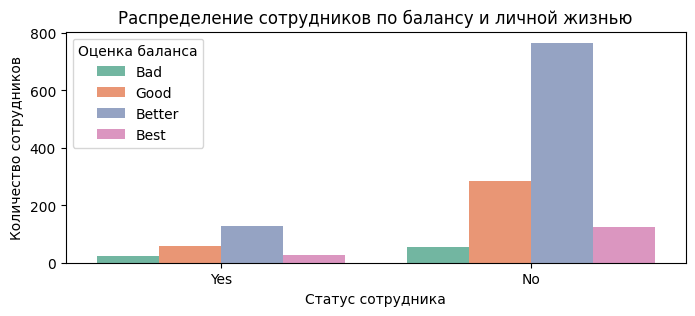

In [ ]:
WorkLifeBalance_labels = ['Bad','Good','Better','Best']
plt.figure(figsize=(8,3))
sns.countplot(x="Attrition", hue="WorkLifeBalance", data=staff, palette='Set2')
plt.title("Распределение сотрудников по балансу и личной жизнью")
plt.xlabel('Статус сотрудника')
plt.ylabel('Количество сотрудников')
plt.legend(labels=WorkLifeBalance_labels, title='Оценка баланса')
plt.show()

По балансу работы и личной жизни многие уволившиеся были вполне довольны. Работа не влияла на личную жизнь негативно.

Уровень вовлеченности в работу.   
1. 'Low'
2. 'Medium'
3. 'High'
4. 'Very High'

In [ ]:
staff.groupby('Attrition')['JobInvolvement'].value_counts().unstack(0)

Attrition,No,Yes
JobInvolvement,,
1,55,28
2,304,71
3,743,125
4,131,13


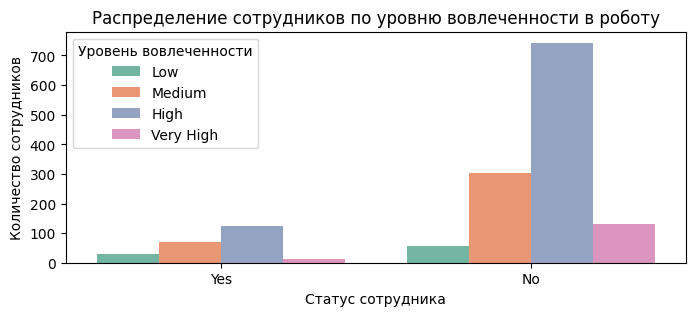

In [ ]:
JobInvolvement_labels = ['Low','Medium','High','Very High']
plt.figure(figsize=(8,3))
sns.countplot(x="Attrition", hue="JobInvolvement", data=staff, palette='Set2')
plt.title("Распределение сотрудников по уровню вовлеченности в роботу")
plt.xlabel('Статус сотрудника')
plt.ylabel('Количество сотрудников')
plt.legend(labels=JobInvolvement_labels, title='Уровень вовлеченности')
plt.show()

Из полученных данных и графика видно что большая часть уволившихся была довольно сильно вовлечена в работу. Эти люди осносились к своей работе ответственно.

Образование.  
1. 'Below College'
2. 'College'
3. 'Bachelor'
4. 'Master'
5. 'Doctor'

In [ ]:
staff.groupby('Attrition')['Education'].value_counts().unstack(0)

Attrition,No,Yes
Education,,
1,139,31
2,238,44
3,473,99
4,340,58
5,43,5


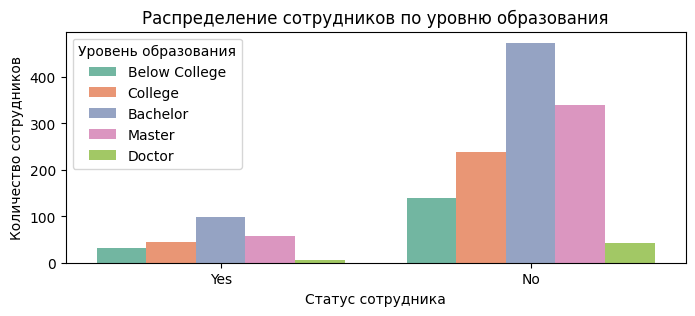

In [ ]:
edu_labels = ['Below College','College','Bachelor','Master','Doctor']
plt.figure(figsize=(8,3))
sns.countplot(x="Attrition", hue="Education", data=staff, palette='Set2')
plt.title("Распределение сотрудников по уровню образования")
plt.xlabel('Статус сотрудника')
plt.ylabel('Количество сотрудников')
plt.legend(labels=edu_labels, title='Уровень образования')
plt.show()

По результатам графика видно, что большая часть уволившихся это люди с уровнем бакалавра,мастера и колледжа.

Общий вывод по психологическим факторам:   

* Среди уволившихся преобладают люди с образованием бакалавра и мастера.
* Уволившиеся показывали хорошую производительность и вовлеченность в работу. Это говорит о том, что сотрудники проявляли ответственность и некоторую инициативу. Им был не безразличен сам результат выполняемой работы.
* Большинство уволившихся устраивали отношения в коллективе. Это говорит о том, что местами присутствовала командная атмосфера.
* При этом уволившихся не очень устраивала окружающая среда и сами условия работы. Возможно сами отношения с непосредственным руководителем были не очень хорошими, также как и  условия работы.
* По критериям удовлетворенности работой,окружающей средой и отношениями, присутствует некоторое отсутствие пропорций в количестве оценок среди уволившихся и оставшихся.

## Анализ зарплаты и расстояния до дома между сотрудниками.

Оценка медианной зарплаты среди сотрудников.

In [ ]:
staff.groupby('Attrition')[['MonthlyIncome', 'MonthlyRate']].median().T

Attrition,No,Yes
MonthlyIncome,5204.0,3202.0
MonthlyRate,14120.0,14618.0


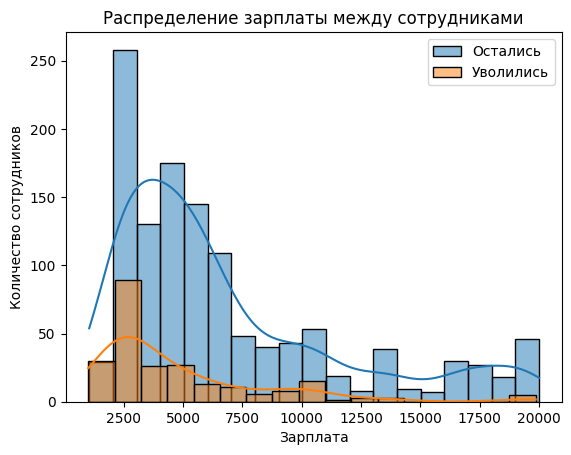

In [ ]:
sns.histplot(staff[staff['Attrition'] == 'No']['MonthlyIncome'],
             label='Остались', kde=True)
sns.histplot(staff[staff['Attrition'] == 'Yes']['MonthlyIncome'],
             label='Уволились', kde=True)
plt.title('Распределение зарплаты между сотрудниками')
plt.ylabel('Количество сотрудников')
plt.xlabel('Зарплата')
plt.legend()
plt.show()

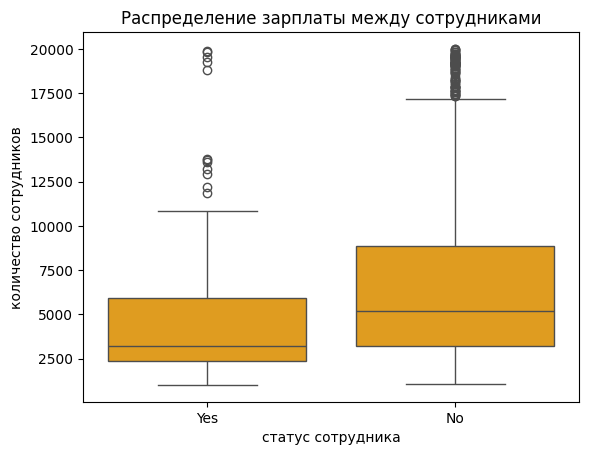

In [ ]:
sns.boxplot(x='Attrition', y='MonthlyIncome', data=staff, color='orange')
plt.title('Распределение зарплаты между сотрудниками')
plt.ylabel('количество сотрудников')
plt.xlabel('статус сотрудника')
plt.show()

Из того, что видно на гистограмме, зарплаты уволившихся значительно ниже, чем у тех, кто остался. При этом тарифная ставка почти одинаковая.

Оценка расстояния до дома среди сотрудников.

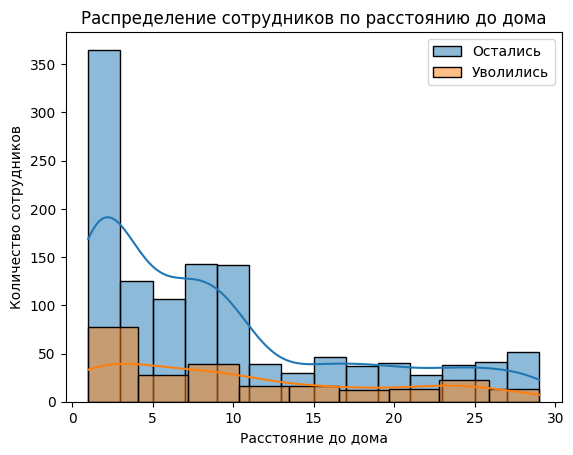

In [ ]:
sns.histplot(staff[staff['Attrition'] == 'No']['DistanceFromHome'],
             label='Остались', kde=True)
sns.histplot(staff[staff['Attrition'] == 'Yes']['DistanceFromHome'],
             label='Уволились', kde=True)
plt.title('Распределение сотрудников по расстоянию до дома')
plt.ylabel('Количество сотрудников')
plt.xlabel('Расстояние до дома')
plt.legend()
plt.show()

Исходя из гистограммы разницы в расстоянии до дома между теми кто уволился и остался почти нет.

Из оценки зарплаты и локации, можно сказать следующее:   

* Факт того, что уволившиеся получали зарплату значительно ниже основой части штата, говорит о том, что это могло послужить причиной увольнений.
* Исходя из того, что в расстоянии до дома между двумя группами сотрудников почти нет разницы, это вряд ли повлияло на увольнение.

## Анализ должностей, отделов и переработок среди сотрудников.

Распределение сотрудников по департаментам.

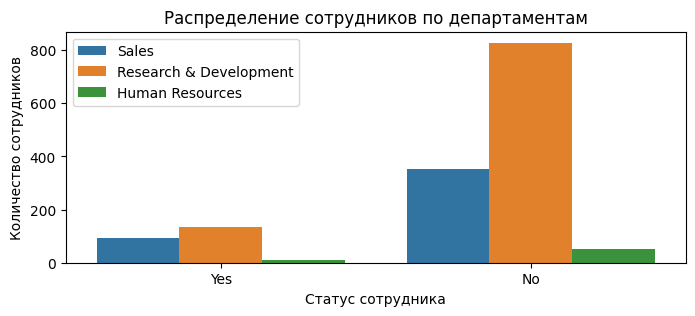

In [ ]:
plt.figure(figsize=(8,3))
sns.countplot(x="Attrition", hue="Department", data=staff)
plt.title("Распределение сотрудников по департаментам")
plt.xlabel('Статус сотрудника')
plt.ylabel('Количество сотрудников')
plt.legend()
plt.show()

Согласно графику основная часть уволившихся работала в отделе продаж и разработок.

Распределение сотрудников по рабочей роли (должности).

<Figure size 1400x1000 with 0 Axes>

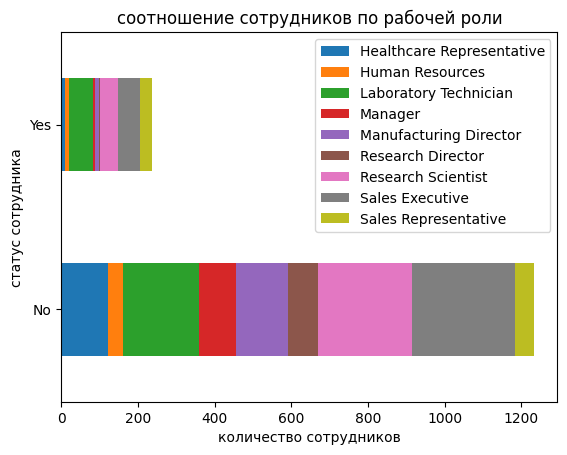

In [ ]:
staff_role = staff.groupby(['Attrition','JobRole']).size().unstack()

plt.figure(figsize=(14,10))
staff_role.plot(kind='barh', stacked=True)
plt.title('соотношение сотрудников по рабочей роли')
plt.xlabel('количество сотрудников')
plt.ylabel('статус сотрудника')
plt.legend()
plt.show()

Согласно графику уволились в основном лаборанты, менеджеры продаж и научные сотрудники.

Распределение сотрудников по переработкам.

<Figure size 1200x800 with 0 Axes>

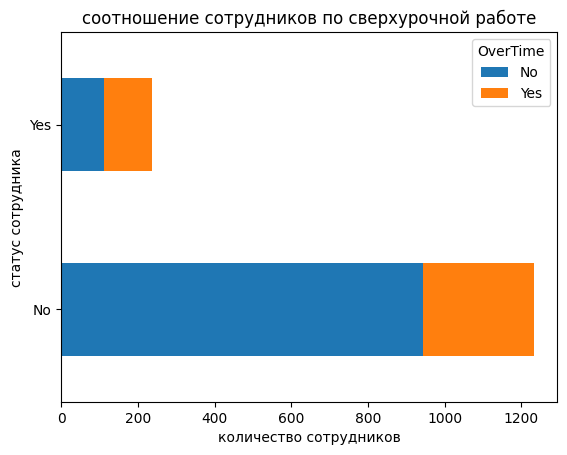

In [ ]:
staff_over = staff.groupby(['Attrition','OverTime']).size().unstack()

plt.figure(figsize=(12 , 8))
staff_over.plot(kind='barh', stacked=True)
plt.title('соотношение сотрудников по сверхурочной работе')
plt.xlabel('количество сотрудников')
plt.ylabel('статус сотрудника')
plt.show()

Исходя из графика половина уволившихся работала сверхурочно.

Предварительные выводы:   

* Уволившиеся получали меньшую зарплату при сверхурочной работе, что могло повлиять на решение об увольнении.
* Среди тех кто уволился есть сотрудники с должностью менеджера продаж, это значит что внутренние факторы подействовали не только на подчиненных.
* Уволившиеся показывали хорошие результаты по производительности и вовлеченности в работу, значит причин для штрафов не было.
* Расстояние до дома между двумя группами сотрудников примерно одинаковое, это порядка до 5 миль или км, что вряд ли могло повлиять на увольнение.
* Большинство уволившихся были не очень довольны условиями работы и отношениями на работе, не исключено что у них были не очень хорошие отношения с непосредственным руководителем. Это могло повлиять на причину ухода.
* При этом по показателям удовлетворенности отношениями на работе и условиями работы среди оставшихся сотрудников можно видеть, что многих все это устраивало. Это может говорить о том, что к уволившимся было предвзятое отношение со стороны руководства.

## Детальный анализ уволившихся сотрудников.

In [ ]:
staff_yes = staff[staff['Attrition']=='Yes']

Количество уволившихся сотрудников по рабочей роли.

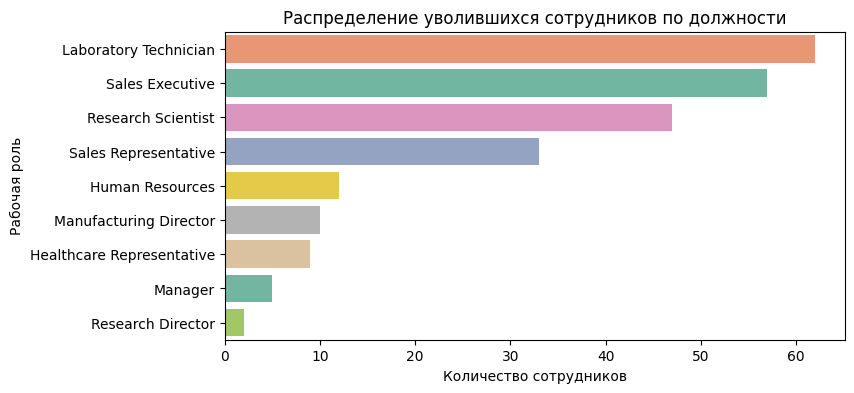

In [ ]:
plt.figure(figsize=(8,4))
sns.countplot(y="JobRole",data=staff_yes,order=staff_yes['JobRole'].value_counts().index,hue="JobRole",palette="Set2")
plt.title("Распределение уволившихся сотрудников по должности")
plt.ylabel('Рабочая роль')
plt.xlabel('Количество сотрудников')
plt.show()

Анализ должностей уволившихся сотрудников подтвердил прошлые результаты, уволились в основном менеджеры продаж, лаборанты и научные сотрудники.

Анализ сотрудников по переработкам с учетом должности.

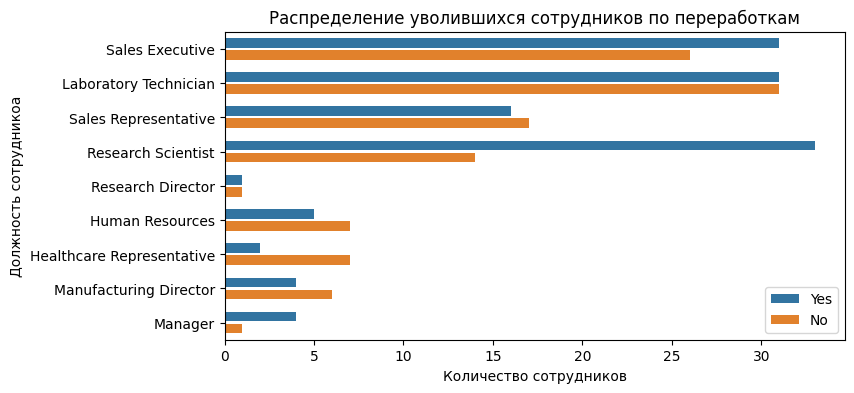

In [ ]:
plt.figure(figsize=(8,4))
sns.countplot (y="JobRole", hue="OverTime", data=staff_yes, width=0.7, gap=0.2)
plt.title("Распределение уволившихся сотрудников по переработкам")
plt.xlabel('Количество сотрудников')
plt.ylabel('Должность сотрудникоа')
plt.legend()
plt.show()

Из графика видно, что в основном сверхурочно работали научные сотрудники, лаборанты, менеджеры продаж и торговые представители.

Удовлетворенность окружающей средой среди уволившихся.

In [ ]:
staff_yes.groupby('JobRole')['EnvironmentSatisfaction'].value_counts().unstack().sort_values(by='JobRole', ascending=False)

EnvironmentSatisfaction,1,2,3,4
JobRole,,,,
Sales Representative,5.0,9.0,10.0,9.0
Sales Executive,18.0,13.0,12.0,14.0
Research Scientist,14.0,4.0,15.0,14.0
Research Director,NaN,1.0,NaN,1.0
Manufacturing Director,2.0,2.0,4.0,2.0
Manager,3.0,1.0,NaN,1.0
Laboratory Technician,22.0,8.0,18.0,14.0
Human Resources,4.0,3.0,2.0,3.0
Healthcare Representative,4.0,2.0,1.0,2.0


Из данных видно, что в основном окружающая среда на работе не устраивала лаборантов, научных сотрудников и менеджеров по продажам.

Удовлетворенность работой среди уволившихся.

In [ ]:
staff_yes.groupby('JobRole')['JobSatisfaction'].value_counts().unstack().sort_values(by='JobRole', ascending=False)

JobSatisfaction,1,2,3,4
JobRole,,,,
Sales Representative,7.0,10.0,9.0,7.0
Sales Executive,16.0,9.0,18.0,14.0
Research Scientist,13.0,10.0,15.0,9.0
Research Director,NaN,1.0,1.0,NaN
Manufacturing Director,2.0,2.0,4.0,2.0
Manager,1.0,2.0,1.0,1.0
Laboratory Technician,20.0,8.0,21.0,13.0
Human Resources,5.0,2.0,3.0,2.0
Healthcare Representative,2.0,2.0,1.0,4.0


Также лаборанты, научные сотрудники и менеджеры по продажам были не очень довольны самой работой.

Удовлетворенность отношениями среди уволившихся.

In [ ]:
staff_yes.groupby('JobRole')['RelationshipSatisfaction'].value_counts().unstack().sort_values(by='JobRole', ascending=False)

RelationshipSatisfaction,1,2,3,4
JobRole,,,,
Sales Representative,4.0,9.0,11.0,9.0
Sales Executive,14.0,9.0,20.0,14.0
Research Scientist,16.0,11.0,12.0,8.0
Research Director,NaN,NaN,NaN,2.0
Manufacturing Director,4.0,3.0,NaN,3.0
Manager,1.0,NaN,NaN,4.0
Laboratory Technician,13.0,11.0,22.0,16.0
Human Resources,1.0,1.0,6.0,4.0
Healthcare Representative,4.0,1.0,NaN,4.0


Исходя из данных большая часть научных сотрудников были не довольны отношениями в коллективе, а вот менеджеры по продажам и лаборанты наоборот, в своем большинстве вполне удовлетворены атмосферой в коллективе.

## Возможные причины увольнений.

На основании полученных графиков, данных уволившихся и сделанных предварительных выводов, можно выделить следующие возможные причины увольнений:   

* Уволившиеся подверглись предвзятому отношению со стороны непосредственного руководителя. Причиной могло послужить то, что сотрудник не имел должного опыта чтобы заслужить одобрение со стороны руководителя.
* Сверхурочный труд уволившихся не был оценен должным образом. Не исключено, что сотрудников необоснованно штрафовали. Также им могли просто не доплатить за сверхурочную работу.
* Повышенный интерес к выполняемой работе и нацеленность на результат также не были оценены. Для начинающего специалиста это может быть критичным моментом.
* Чрезмерный объем выполняемых задач возложенный на новых сотрудников.

# Построение модели для дальнейшего прогнозирования возможных увольнений.

Цель построения:   
Заранее находить сотрудников которые могут уволиться.

Столбец Attrition Целевая переменная (Уволился — Yes, Остался — No).  
Все остальные столбцы признаки.

In [ ]:
model_logistic = LogisticRegression(random_state=1)
model_random = RandomForestClassifier(random_state=1)

y = staff['Attrition'].map({'Yes': 1, 'No': 0})
x = pd.get_dummies(staff.drop(columns='Attrition'))

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=1, test_size=0.2)

## Построение моделей логистической регрессии и случайного леса.

Обучение моделей.

In [ ]:
model_logistic.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=1)

In [ ]:
model_random.fit(x_train,y_train)

RandomForestClassifier(random_state=1)

Проверка точности моделей через метрики классификации по обучающей выборке.

In [ ]:
model_logistic.predict
y_pred_train = model_logistic.predict(x_train)
model_random.predict
y_pred_train2 = model_random.predict(x_train)

print('Логистическая регрессия')
print(classification_report(y_train, y_pred_train))
print('Случайный лес')
print(classification_report(y_train, y_pred_train2))

Логистическая регрессия
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       997
           1       1.00      0.02      0.03       179

    accuracy                           0.85      1176
   macro avg       0.92      0.51      0.48      1176
weighted avg       0.87      0.85      0.78      1176

Случайный лес
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       997
           1       1.00      1.00      1.00       179

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



Проверка точности моделей через метрики классификации на тестовой выборке.

In [ ]:
model_logistic.predict
y_pred = model_logistic.predict(x_test)
model_random.predict
y_pred2 = model_random.predict(x_test)

print('Логистическая регрессия')
print(classification_report(y_test, y_pred ) )
print('Случайный лес')
print(classification_report(y_test, y_pred2 ) )

Логистическая регрессия
              precision    recall  f1-score   support

           0       0.80      1.00      0.89       236
           1       0.00      0.00      0.00        58

    accuracy                           0.80       294
   macro avg       0.40      0.50      0.44       294
weighted avg       0.64      0.80      0.71       294

Случайный лес
              precision    recall  f1-score   support

           0       0.83      0.99      0.90       236
           1       0.75      0.16      0.26        58

    accuracy                           0.82       294
   macro avg       0.79      0.57      0.58       294
weighted avg       0.81      0.82      0.77       294



Результаты:   
* Precision логистической регрессии показывает, что когда модель помечает сотрудника как увольняющегося, она оказывается права только в 0 % случаев.   
* Recall логистической регрессии показывает, что из всех 58 сотрудников которые реально уволились модель смогла вычислить только 0 %.  
* Фактически с базовыми параметрами логистическая регрессия относит всех сотрудников к тем, кто остался. Это происходит из-за дисбаланса классов и сильного переобучения.
* Precision показывает, что случайный лес помечает сотрудника как увольняющегося в 75 % случаев, что значительно выше, чем у логистической регрессии.
* Recall показывает, что из всех 58 сотрудников которые реально уволились случайный лес вычислил правильно 16 %, что также выше, чем у логистической регрессии.
* Фактически с базовыми параметрами случайный лес также относит почти всех сотрудников к тем, кто остался. Также сказывается дисбаланс классов и сильное переобучение.

### Оптимизация моделей логистической регрессии и случайного леса.

Нормализация данных и генерация дополнительных данных для меньшего класса, чтобы исправить дисбаланс классов.

In [ ]:
scaler = StandardScaler()

x_scaler = scaler.fit_transform(x_train)
x_scaler_test = scaler.transform(x_test)

samp = RandomOverSampler(sampling_strategy={0:1200,1:1200}, random_state=1)

x_samp_train, y_samp_train = samp.fit_resample(x_scaler, y_train)

Автоматический подбор параметров моделей.

In [ ]:
param_grid = {
    'C': [0.01, 0.1, 1, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'random_state': [1,10,20,30,40]
}

grid = GridSearchCV(model_logistic, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(x_samp_train, y_samp_train)
best_params = grid.best_params_
print(best_params)

{'C': 4, 'penalty': 'l1', 'random_state': 1, 'solver': 'liblinear'}


In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [5, 10, 20, 25, 30],
    'min_samples_leaf': [1, 2, 4, 6, 8],
    'min_samples_split': [2, 5, 10, 15, 20],
    'max_features': ['sqrt', 'log2', 0.5],
    'bootstrap': [True, False]
}

grid2 = RandomizedSearchCV(model_random, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid2.fit(x_samp_train, y_samp_train)
best_params2 = grid2.best_params_
print(best_params2)

{'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': False}


Проверка метрик точности на обучающей выборке.

In [ ]:
grid_model = grid.best_estimator_
grid_model.predict
y_pred_grid = grid_model.predict(x_samp_train)
regresion = classification_report(y_samp_train, y_pred_grid, output_dict=True)
logistic_regression = pd.DataFrame(regresion).T

grid_model2 = grid2.best_estimator_
grid_model2.predict
y_pred_grid_train = grid_model2.predict(x_samp_train)
forest = classification_report(y_samp_train, y_pred_grid_train, output_dict=True)
random_forest = pd.DataFrame(forest).T

print('Логистическая регрессия на обучении')
print(logistic_regression.round(2))
print('Случайный лес на обучении')
print(random_forest.round(2))

Логистическая регрессия на обучении
              precision  recall  f1-score  support
0                  0.79    0.77      0.78  1200.00
1                  0.78    0.80      0.79  1200.00
accuracy           0.79    0.79      0.79     0.79
macro avg          0.79    0.79      0.79  2400.00
weighted avg       0.79    0.79      0.79  2400.00
Случайный лес на обучении
              precision  recall  f1-score  support
0                   1.0     1.0       1.0   1200.0
1                   1.0     1.0       1.0   1200.0
accuracy            1.0     1.0       1.0      1.0
macro avg           1.0     1.0       1.0   2400.0
weighted avg        1.0     1.0       1.0   2400.0


Проверка метрик точности на тестовой выборке.

In [ ]:
y_pred_grid2 = grid_model.predict(x_scaler_test)
regresion2 = classification_report(y_test, y_pred_grid2, output_dict=True)
logistic_regression2 = pd.DataFrame(regresion2).T

y_pred_grid_test = grid_model2.predict(x_scaler_test)
forest2 = classification_report(y_test, y_pred_grid_test, output_dict=True)
random_forest2 = pd.DataFrame(forest2).T

print('Логистическая регрессия на тестовой')
print(logistic_regression2.round(2))
print('Случайный лес на тестовой')
print(random_forest2.round(2))

Логистическая регрессия на тестовой
              precision  recall  f1-score  support
0                  0.92    0.72      0.81   236.00
1                  0.40    0.76      0.52    58.00
accuracy           0.73    0.73      0.73     0.73
macro avg          0.66    0.74      0.67   294.00
weighted avg       0.82    0.73      0.75   294.00
Случайный лес на тестовой
              precision  recall  f1-score  support
0                  0.84    0.98      0.91   236.00
1                  0.78    0.24      0.37    58.00
accuracy           0.84    0.84      0.84     0.84
macro avg          0.81    0.61      0.64   294.00
weighted avg       0.83    0.84      0.80   294.00


Графики матриц ошибок.

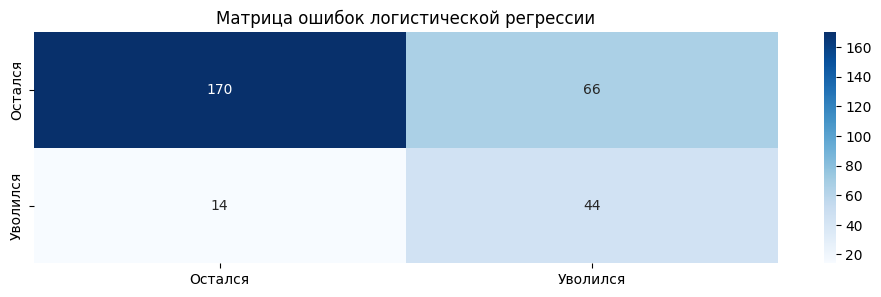

In [ ]:
matrix_logistic = confusion_matrix(y_test, y_pred_grid2)

plt.figure(figsize=(12,3))
sns.heatmap(matrix_logistic, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Остался', 'Уволился'],
            yticklabels=['Остался', 'Уволился'])

plt.title('Матрица ошибок логистической регрессии')
plt.show()

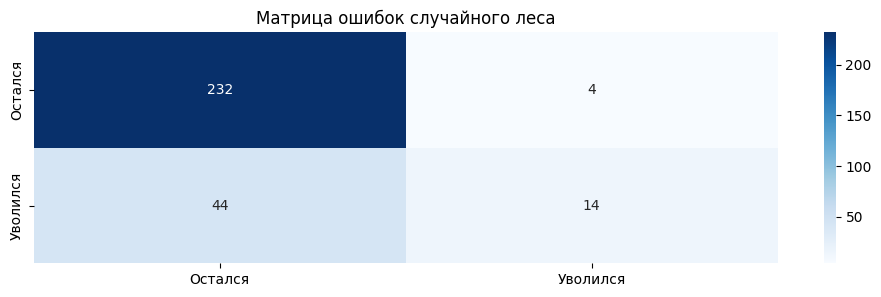

In [ ]:
matrix_random = confusion_matrix(y_test, y_pred_grid_test)

plt.figure(figsize=(12,3))
sns.heatmap(matrix_random, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Остался', 'Уволился'],
            yticklabels=['Остался', 'Уволился'])

plt.title('Матрица ошибок случайного леса')
plt.show()

Результаты после оптимизации:

* Precision логистической регрессии показывает, что модель помечает сотрудника как увольняющегося также в 40 % случаев.
* Recall логистической регрессии показывает, что из всех 58 сотрудников которые реально уволились модель смогла вычислить уже 76 %. Это означает, что из 58 уволившихся сотрудников модель правильно нашла 44 сотрудника которые реально уволились.
* По метрикам точности на обучающей и тестовой выборки, у логистической регрессии присутствует некоторое переобучение, но не критичное.
* Precision показывает, что случайный лес помечает сотрудника как увольняющегося уже в 78 % случаев, что незначительно выше до оптимизации.
* Recall показывает, что из всех 58 сотрудников которые реально уволились случайный лес смог вычислить уже 24 %. Это означает, что из 58 уволившихся сотрудников случайный лес правильно нашел 14 сотрудников которые реально уволились.
* По метрикам точности на обучающей и тестовой выборки присутствует очень сильное переобучение, случайный лес просто запоминает правильные значения из данных.

## Выводы по результатам построения двух алгоритмов.

На основании результатов метрик точности прогнозирования логистической регрессии и случайного леса, можно сделать следующие выводы в пользу первого алгоритма:

* Precision (Точность) — 0.40 (40%), этот показатель говорит о качестве прогноза. Из всех сотрудников, которых модель пометила меткой «уволится», только 40% реально покинули компанию. В остальных 60% случаев модель выдала ложную тревогу на лояльных сотрудников.
Бизнес-смысл: Модель склонна перестраховываться и искать риски там, где их нет.
* Recall (Полнота) — 0.76 (76%), это главный успех логистической регрессии перед случайным лесом. Она смогла вычислить и распознать 76% всех реально уволившихся сотрудников. Она пропустила лишь каждого четвертого (24%), что является отличным показателем.
Бизнес-смысл: Мы видим подавляющее большинство людей в зоне риска.
* F1-score — 0.52, это сбалансированная метрика. Она подтверждает, что логистическая регрессия работает стабильно. Значение выше 0.5 для такой несбалансированной выборки (где увольняющихся мало) считается хорошим рабочим результатом.
* Несмотря на умеренную точность (Precision 0.40), логистическая регрессия обладает высокой прогностической силой по сравнению со случайным лесом, обнаруживая 76% (Recall) сотрудников, намеревающихся уйти, при этом показывая лишь незначительное переобучение. В тоже время у случайного леса этот показатель равен лишь 24 %.

# Общие выводы.

* Уволившиеся получали меньшую зарплату при сверхурочной работе, что могло повлиять на решение об увольнении.
* Среди тех кто уволился есть сотрудники с должностью менеджера продаж, это значит, что внутренние факторы подействовали не только на подчиненных.
* Уволившиеся показывали хорошие результаты по производительности и вовлеченности в работу, значит причин для штрафов не было.
* Расстояние до дома между двумя группами сотрудников примерно одинаковое, это порядка до 5 миль или км, что вряд ли могло повлиять на увольнение.
* Большинство уволившихся были не очень довольны условиями работы и отношениями на работе, не исключено что у них были не очень хорошие отношения с непосредственным руководителем. Это могло повлиять на причину ухода.
* При этом по показателям удовлетворенности отношениями на работе и условиями работы среди оставшихся сотрудников можно видеть, что многих все это устраивало. Это может говорить о том, что к уволившимся было предвзятое отношение со стороны руководства.
* Уволившиеся подверглись предвзятому отношению со стороны непосредственного руководителя. Причиной могло послужить то, что сотрудник не имел должного опыта чтобы заслужить одобрение со стороны руководителя.
* Сверхурочный труд уволившихся не был оценен должным образом. Не исключено, что сотрудников необоснованно штрафовали. Также им могли просто не доплатить за сверхурочную работу.
* Повышенный интерес к выполняемой работе и нацеленность на результат также не были оценены. Для начинающего специалиста это может быть критичным моментом.
* Чрезмерный объем выполняемых задач возложенный на новых сотрудников.

# Рекомендации стейкхолдерам.

* Анонимные опросы сотрудников об условиях работы и взаимоотношениях в коллективе. Это поможет увидеть объективную картину и выявить токсичных руководителей до того, как от них разбежится весь отдел.
* Проверить систему выплат за переработки. Если сотрудники уходят, значит, либо им мало платят за это, либо они выгорают морально. Нужно либо нанять еще людей, чтобы распределить нагрузку, либо увеличить бонус за переработки.
* Внедрить программу менторства для молодых кадров и закрепить за каждым новичком опытного напарника, который поможет адаптироваться.
* Использовать обученную ML-модель для раннего предупреждения увольнений. Периодически давать модели новые данные. Если сотрудник попал в зону риска, HR-менеджер должен провести разговор по душам.
